# PHÂN LOẠI RƯỢU VANG VỚI THUẬT TOÁN CÂY QUYẾT ĐỊNH

In [2]:
import pandas as pd
import numpy as np
import random as rnd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import datasets

## **Tập dữ liệu rượu vang**

Tập dữ liệu rượu vang là kế quả của một phân tích của sự phát triển rượu trong cùng khu vực ở Italy nhưng đã được chuyển từ 3 giống cây trồng khác nhau. Những phân tích quyết tâm chất lượng của 13 đặc tính được tìm thấy trong mỗi 3 loại rượu. Nhiệm vụ của chúng ta là phân loại 3 loại rượu dựa trên những đặc tính bên dưới

In [3]:
# tải tập dữ liệu
dataset = datasets.load_wine()
X= dataset.data
y= dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [4]:
data_df = pd.DataFrame(X, columns=dataset.feature_names)
data_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


## Mô hình

Trong ví dụ này, chúng ta chọn mô hình cây quyết định để phân loại 3 loại rượu. Chúng ta sử dụng lớp DecisionTreeClassifer trong sklearn với max_depth = 4. max_depth là đội sâu tối đa của cây.

In [5]:
model = DecisionTreeClassifier(max_depth=4, )
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Dự đoán và đánh giá

In [6]:
y_pred = model.predict(X_test)
print(f"Classification report for DecisionTree: \n"
      f"{metrics.classification_report(y_test, y_pred)} \n")

Classification report for DecisionTree: 
              precision    recall  f1-score   support

           0       0.89      0.94      0.92        18
           1       0.93      0.88      0.90        16
           2       0.91      0.91      0.91        11

    accuracy                           0.91        45
   macro avg       0.91      0.91      0.91        45
weighted avg       0.91      0.91      0.91        45
 



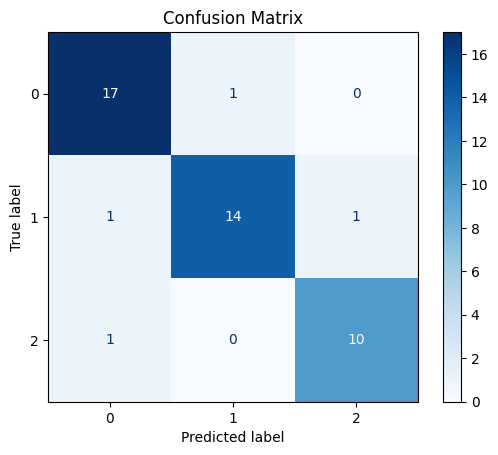

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

AttributeError: module 'sklearn.metrics' has no attribute 'plot_confusion_matrix'

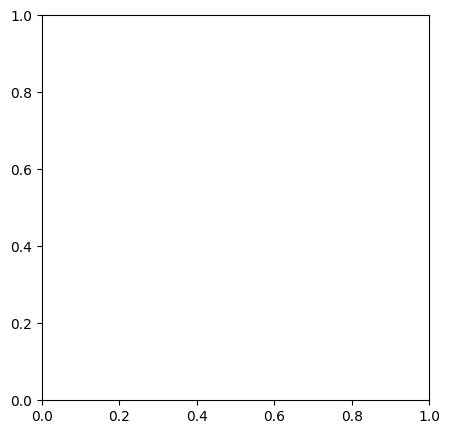

In [7]:
# Biểu đồ ma trận trực quan
plt.figure(figsize=(5,5))
ax = plt.gca()
disp = metrics.plot_confusion_matrix(model, X_test, y_test, ax = ax)
_ = disp.figure_.suptitle("Confusion Matrix", fontsize = 15)

AttributeError: feature_name

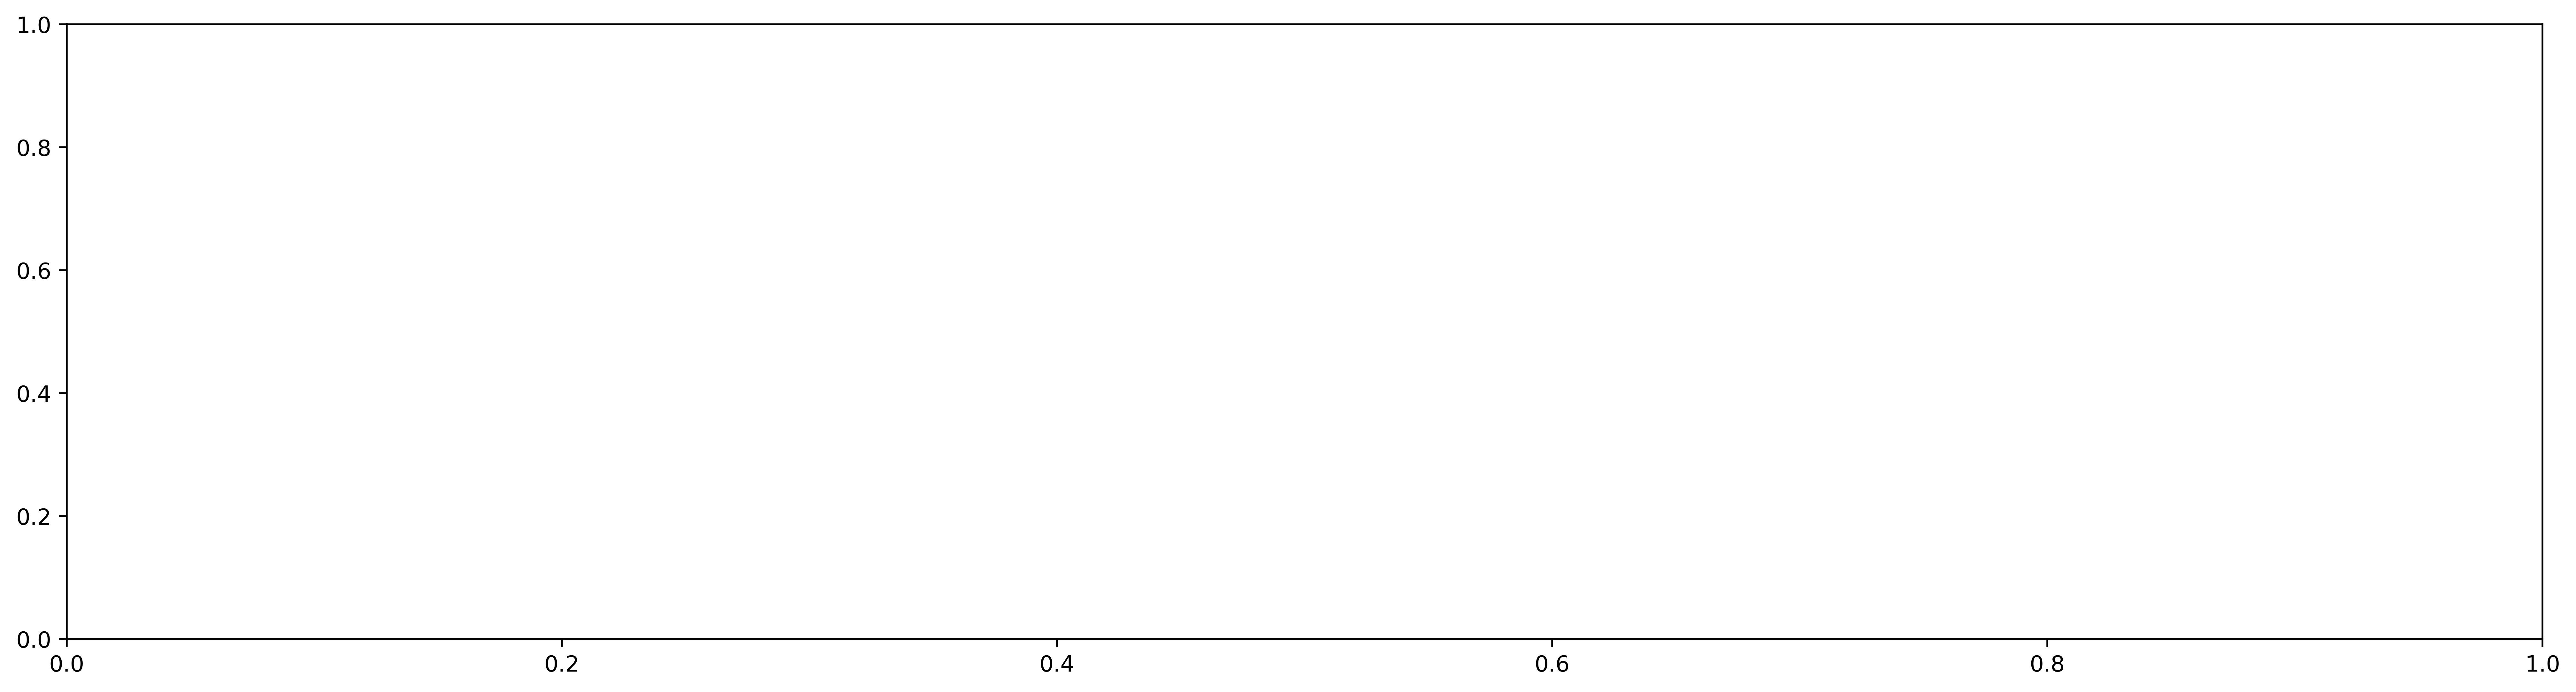

In [9]:
# Hiển thị cây quyết định

fig, axes = plt.subplots(nrows= 1, ncols = 1, figsize = (20,5), dpi = 500)

tree.plot_tree(model, feature_names=dataset.feature_name, class_names = dataset.target_names, filled=True)

## Decision bounday

In [ ]:

 # Plot the decision boundary 
n_classes = 3 
plot_colors = "ryb" 
plot_step = 0.02 
font = {'size'   : 25} 
plt.figure(figsize=(30, 20)) 
plt.suptitle("Decision surface of a decision tree using paired features", **{'size': 30}) 
for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], 
[1, 2], [1, 3], [2, 3]]): 
plt.subplot(2, 3, pairidx + 1) 
X = X_train[:, pair] 
clf = DecisionTreeClassifier().fit(X, y_train) 
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1 
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1 
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), 
np.arange(y_min, y_max, plot_step)) 
plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5) 
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]) 
Z = Z.reshape(xx.shape) 
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu) 
plt.xlabel(dataset.feature_names[pair[0]], **font) 
plt.ylabel(dataset.feature_names[pair[1]], **font) 
# Show the training points 
for i, color in zip(range(n_classes), plot_colors): 
idx = np.where(y_train == i) 
plt.scatter(X[idx, 0], X[idx, 1], c=color, label=dataset.target_names[i], 
cmap=plt.cm.RdYlBu, edgecolor='black', s=30)     
plt.legend(loc='lower right', borderpad=0, handletextpad=0) 